In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Carichiamo i dataset
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
green = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json", on_invalid="ignore")
flood = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\overstroming_geojson_lnglat.json")

print(f"Quartieri: {len(buurten)}")
print(f"Aree verdi: {len(green)}")
print(f"Zone rischio: {len(flood)}")

Quartieri: 518
Aree verdi: 125
Zone rischio: 183


In [2]:
# Verde per Stadsdeel
verde_stadsdeel = green.groupby('Stadsdeel')['Oppervlakte_m2'].sum() / 1_000_000
verde_stadsdeel = verde_stadsdeel.reset_index()
verde_stadsdeel.columns = ['Stadsdeel', 'Verde_km2']

# Rischio per Stadsdeel — prima uniamo al layer geografico
flood['rischio'] = flood['Kans'].map({
    'Geen significante overstromingskans': 0,
    'Extreem kleine kans: <1/30.000 per jaar': 1,
    'Zeer kleine kans: 1/3.000 tot 1/30.000 per jaar': 2,
    'Kleine kans: 1/300 tot 1/3.000 per jaar': 3
})

flood_proj = flood.to_crs(buurten.crs)
buurten_proj = buurten.copy()

# Uniamo rischio ai buurten per posizione
joined_flood = gpd.sjoin(buurten_proj, flood_proj[['rischio', 'geometry']], 
                          how='left', predicate='intersects')

rischio_stadsdeel = joined_flood.groupby('Stadsdeel')['rischio'].mean().reset_index()
rischio_stadsdeel.columns = ['Stadsdeel', 'Rischio_medio']

print(verde_stadsdeel)
print(rischio_stadsdeel)

    Stadsdeel  Verde_km2
0  Amstelveen   9.192494
1     Centrum   0.082263
2      Diemen   0.094902
3  Nieuw-West   5.862203
4       Noord   2.726583
5        Oost   1.849505
6        West   0.557488
7        Zuid   1.819623
8    Zuidoost   5.251325
    Stadsdeel  Rischio_medio
0     Centrum       0.589552
1  Nieuw-West       1.456349
2       Noord       1.697479
3        Oost       0.859848
4       Weesp       2.666667
5        West       0.970501
6   Westpoort       1.111111
7        Zuid       0.665653
8    Zuidoost       1.607477


In [3]:
# Uniamo le due tabelle per Stadsdeel
correlazione = verde_stadsdeel.merge(rischio_stadsdeel, on='Stadsdeel', how='inner')
print(correlazione)

    Stadsdeel  Verde_km2  Rischio_medio
0     Centrum   0.082263       0.589552
1  Nieuw-West   5.862203       1.456349
2       Noord   2.726583       1.697479
3        Oost   1.849505       0.859848
4        West   0.557488       0.970501
5        Zuid   1.819623       0.665653
6    Zuidoost   5.251325       1.607477


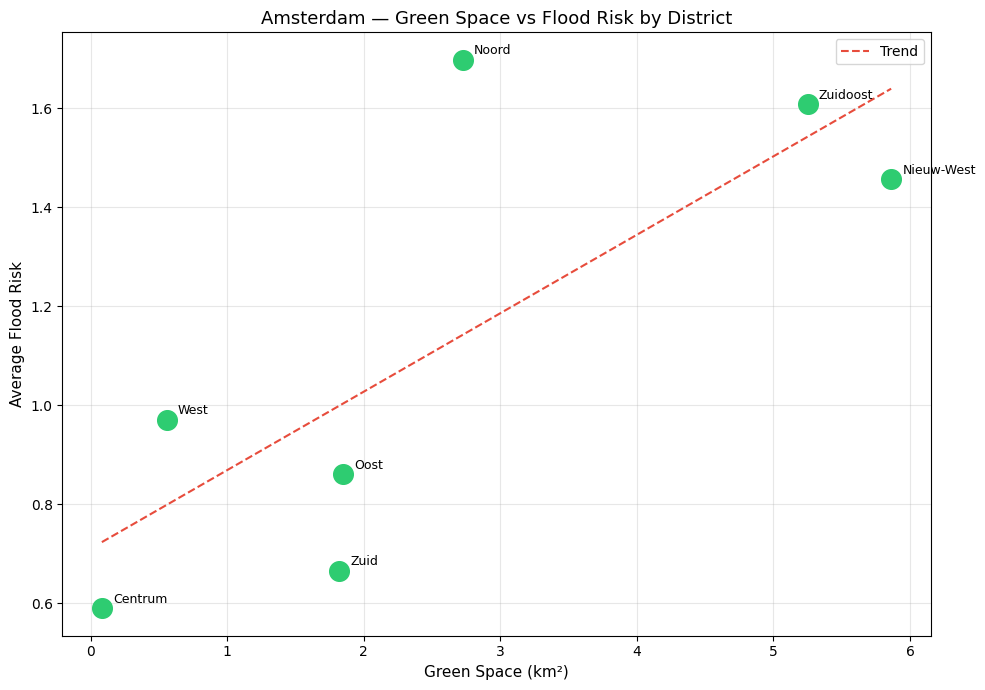

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

# Punto per ogni Stadsdeel
for _, row in correlazione.iterrows():
    ax.scatter(row['Verde_km2'], row['Rischio_medio'], 
               s=200, color='#2ecc71', zorder=5)
    ax.annotate(row['Stadsdeel'], 
                xy=(row['Verde_km2'], row['Rischio_medio']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9)

# Linea di tendenza
z = np.polyfit(correlazione['Verde_km2'], correlazione['Rischio_medio'], 1)
p = np.poly1d(z)
x_line = np.linspace(correlazione['Verde_km2'].min(), 
                     correlazione['Verde_km2'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#e74c3c', linewidth=1.5, 
        label='Trend')

ax.set_xlabel('Green Space (km²)', fontsize=11)
ax.set_ylabel('Average Flood Risk', fontsize=11)
ax.set_title('Amsterdam — Green Space vs Flood Risk by District', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('amsterdam_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from scipy import stats

# Coefficiente di correlazione di Pearson
r, p_value = stats.pearsonr(correlazione['Verde_km2'], correlazione['Rischio_medio'])

print(f"Coefficiente di correlazione (r): {r:.3f}")
print(f"P-value: {p_value:.3f}")

if abs(r) > 0.7:
    forza = "forte"
elif abs(r) > 0.4:
    forza = "moderata"
else:
    forza = "debole"

direzione = "positiva" if r > 0 else "negativa"
print(f"\nCorrelazione {direzione} e {forza}")

Coefficiente di correlazione (r): 0.764
P-value: 0.045

Correlazione positiva e forte
